# Plot Synthetic Tree Results

This notebook loads results from `run.py` and plots value estimation error for UCT, MENTS, RENTS, TENTS, DENTS, BTS, and VarDE.


In [8]:
from pathlib import Path
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [9]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",

    # Embed fonts as TrueType (selectable/searchable)
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # sizes (tune if you want)
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Times-like fonts, matching paper
    "text.latex.preamble": r"""
        \usepackage{newtxtext}
        \usepackage{newtxmath}
    """,
})

In [10]:
# Set this to a specific run directory if needed
run_dir = None

base_dir = Path("logs/runs")
if run_dir is None:
    runs = sorted(base_dir.glob("run_*"), key=lambda p: p.stat().st_mtime)
    if not runs:
        raise FileNotFoundError("No run directories found under logs/runs.")
    run_dir = runs[-1]
else:
    run_dir = Path(run_dir)

print(f"Using run directory: {run_dir}")

Using run directory: logs\runs\run_20260127_123015


In [11]:
with open(run_dir / "config.json", "r", encoding="utf-8") as handle:
    config = json.load(handle)

algorithms = config["algorithms"]
kds = [(item["k"], item["d"]) for item in config["kds"]]
n_exp = config["n_exp"]
n_trees = config["n_trees"]
n_simulations = config["n_simulations"]

print("Algorithms:", algorithms)
print("k,d pairs:", kds)
print("n_exp, n_trees, n_simulations:", n_exp, n_trees, n_simulations)


Algorithms: ['uct', 'ments', 'rents', 'tents', 'dents', 'bts', 'varde']
k,d pairs: [(16, 1), (200, 1), (14, 3), (16, 3), (16, 4), (200, 2)]
n_exp, n_trees, n_simulations: 5 5 1000


In [12]:
kds = [(16, 1), (14, 3), (16, 4), (200, 2)]

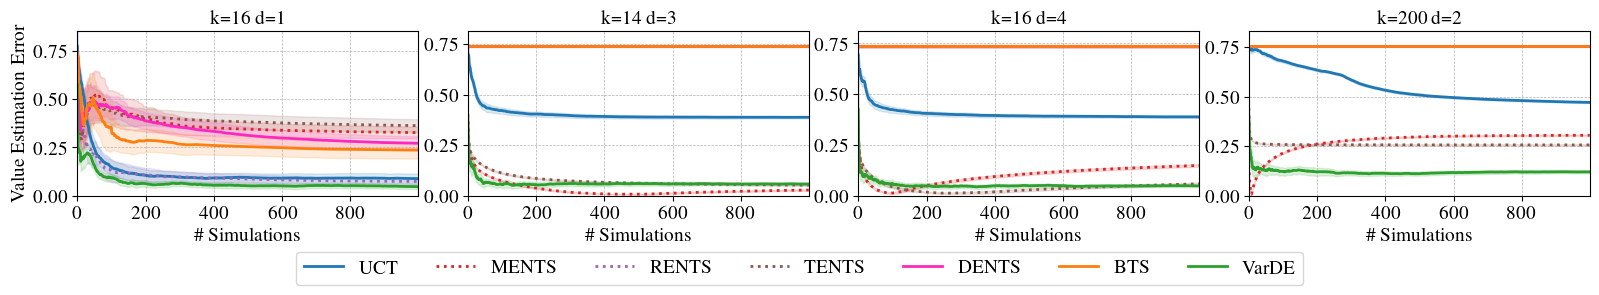

In [14]:
labels = {
    "uct": "UCT",
    "ments": "MENTS",
    "rents": "RENTS",
    "tents": "TENTS",
    "dents": "DENTS",
    "bts": "BTS",
    "varde": "VarDE",
}

colors = {
    "uct": "#1f77b4",
    "ments": "#d62728",
    "rents": "#9467bd",
    "tents": "#8c564b",
    "dents": "#ff27be",
    "bts": "#ff7f0e",
    "varde": "#2ca02c",
}

fig, axes = plt.subplots(1, len(kds), figsize=(4 * len(kds), 3), squeeze=False)
axes = axes[0]

for ax, (k, d) in zip(axes, kds):
    max_val = 0.0
    for alg in algorithms:
        path = run_dir / "results" / f"k_{k}_d_{d}" / f"diff_uct_{alg}.npy"
        if not path.exists():
            print(f"Missing {path}")
            continue
        diff_uct = np.load(path)
        avg = diff_uct.mean(axis=0)
        flat = diff_uct.reshape(n_exp * n_trees, n_simulations)
        err = 2 * flat.std(axis=0) / np.sqrt(n_exp * n_trees)
        linestyle = ':' if alg in {'ments', 'rents', 'tents'} else '-'
        ax.plot(avg, color=colors.get(alg), linestyle=linestyle, linewidth=2.0, label=labels.get(alg, alg))
        ax.fill_between(np.arange(n_simulations), avg - err, avg + err, color=colors.get(alg), alpha=0.15)
        max_val = max(max_val, float(avg.max()))

    ax.set_title(f"k={k} d={d}")
    ax.set_xlabel("\# Simulations")
    if ax is axes[0]:
        ax.set_ylabel("Value Estimation Error")
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.set_xlim(0, n_simulations - 1)
    ax.set_ylim(0, max_val * 1.1 if max_val > 0 else 1.0)

handles, labels_list = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_list, loc="lower center", ncol=len(labels_list), frameon=True, framealpha=0.8)
fig.tight_layout()
fig.subplots_adjust(bottom=0.33)
plt.savefig(run_dir / "stree.pdf")